# Inductive Miner & Escaping Edges

In [78]:
import pm4py
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.objects.conversion.process_tree import converter as pt_converter

## Load Event Log
Read an XES file for process discovery.

In [79]:
LOG_PATH = "../data/examples/running-example.xes"
event_log = log_converter.apply(pm4py.read_xes(LOG_PATH))

print(f"Traces: {len(event_log)}")

parsing log, completed traces ::   0%|          | 0/6 [00:00<?, ?it/s]

Traces: 6


## Discover Process Tree
Use the Inductive Miner to discover a process tree from the event log.

In [80]:
process_tree = pm4py.discover_process_tree_inductive(event_log)

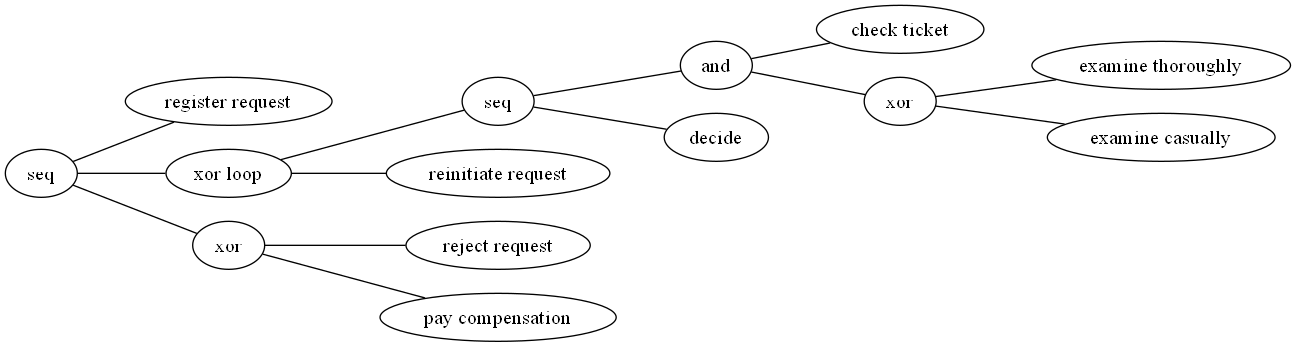

In [81]:
pm4py.view_process_tree(process_tree)

## Model Evaluation Metrics
Define a function that computes fitness, precision, F1, CFC, and model size by converting the process tree to a Petri net and running alignment-based conformance checking.

In [82]:
def calculate_metrics(model, event_log):
    """
    Computes fitness, precision, F1, CFC, and model size for a process model
    with respect to an event log.

    Args:
        model: A PM4Py ProcessTree, or a PetriNet tuple (net, initial_marking, final_marking).
        event_log: PM4Py EventLog object.

    Returns:
        dict: {"fi" (fitness), "pr" (precision), "F1", "CFC", "size"}.
    """
    if hasattr(model, 'children'):
        net, initial_marking, final_marking = pt_converter.apply(model)
    elif isinstance(model, tuple) and len(model) == 3:
        net, initial_marking, final_marking = model
    else:
        raise TypeError(f"Expected a ProcessTree or (PetriNet, marking, marking) tuple, got {type(model)}")

    log_fitness = pm4py.fitness_alignments(event_log, net, initial_marking, final_marking, multi_processing=False)['log_fitness']
    precision = pm4py.precision_alignments(event_log, net, initial_marking, final_marking, multi_processing=False)

    denominator = log_fitness + precision
    f1 = 2 * (log_fitness * precision) / denominator if denominator != 0 else 0.0

    size = len(net.places) + len(net.transitions) + len(net.arcs)

    return {
        "fi": log_fitness,
        "pr": precision,
        "F1": f1,
        "size": size
    }

## Compute Metrics
Evaluate the discovered model on the same event log.

In [83]:
metrics = calculate_metrics(process_tree, event_log)

print("=" * 50)
print("MODEL EVALUATION METRICS")
print("=" * 50)
print(f"Fitness:           {metrics['fi']:.4f}")
print(f"Precision:         {metrics['pr']:.4f}")
print(f"F1 Score:          {metrics['F1']:.4f}")
print(f"Model Size:        {metrics['size']}")

aligning log, completed variants ::   0%|          | 0/6 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/23 [00:00<?, ?it/s]

MODEL EVALUATION METRICS
Fitness:           1.0000
Precision:         0.7531
F1 Score:          0.8591
Model Size:        41


## Escaping Edges (Align-ETConformance)

The Align-ETConformance precision algorithm internally computes **escaping edges** for each log prefix:
- **Activated transitions**: transitions enabled in the model after replaying the prefix
- **Log transitions (reflected tasks)**: activities that actually follow the prefix in the log
- **Escaping edges** = activated \ log — behavior the model allows but the log never shows

The custom module below wraps the PM4Py source to return these details instead of just the aggregate precision score.

In [84]:
import sys
sys.path.insert(0, "..\\scripts")

import custom_precision_variants_align_etconformance as custom_ae

# Convert process tree to Petri net for the custom precision function
net, im, fm = pt_converter.apply(process_tree)

In [85]:
# Run custom Align-ETConformance that exposes escaping edges
result = custom_ae.apply(event_log, net, im, fm)

print("=" * 50)
print("CUSTOM ALIGN-ETCONFORMANCE RESULT")
print("=" * 50)
print(f"Precision:              {result['precision']:.4f}")
print(f"Sum escaping edges:     {result['sum_ee']}")
print(f"Sum activated trans:    {result['sum_at']}")
print(f"Unfit prefixes (count): {result['unfit']}")
print(f"Total prefixes tracked: {len(result['prefixes'])}")

computing precision with alignments, completed variants ::   0%|          | 0/23 [00:00<?, ?it/s]

CUSTOM ALIGN-ETCONFORMANCE RESULT
Precision:              0.7531
Sum escaping edges:     20
Sum activated trans:    81
Unfit prefixes (count): 0
Total prefixes tracked: 23


## Interpreting Escaping Edges

**`df_prefixes`** — one row per log prefix, ranked by *Impact* (Support × |EE|).  
This surfaces which process states contribute the most escaping behavior. For example, a prefix seen in 10 traces with 1 escaping edge has Impact = 10.

| Column | Meaning |
|--------|---------|
| `Prefix` | The sequence of activities observed so far |
| `Support` | How many traces in the log reach this prefix |
| `EE` | Number of escaping edges at this prefix |
| `Impact` | `Support × EE` — higher means more cases affected |
| `Escaping Edges` | The specific activities the model allows but the log never shows next |

In [86]:
import pandas as pd
from pm4py.util import constants as pm4py_constants

VSEP = pm4py_constants.DEFAULT_VARIANT_SEP

pd.set_option("display.max_colwidth", None)

# -------------------------------------------------------------------
# Helper: left-align text columns in a displayed DataFrame
# -------------------------------------------------------------------
def left_align(df):
    text_cols = df.select_dtypes(include="string").columns
    return df.style.set_properties(
        subset=text_cols,
        **{"text-align": "left"}
    )

# -------------------------------------------------------------------
# df_prefixes  —  one row per prefix, ranked by Impact
#
# Each row lists the corpus support (# of traces reaching this
# prefix), the number of escaping edges at this state (|EE|), and
# their product (Impact) to surface even rare prefixes that have
# high per-prefix escaping edges.
# -------------------------------------------------------------------

rows = []

for prefix, data in result["prefixes"].items():
    if data.get("unfit", False):
        continue   # skip prefixes that could not be aligned

    rows.append({
        "Prefix": " → ".join(prefix.split(VSEP)),
        "Support": data["count"],          # how many traces reach this prefix
        "|EE|": data["n_ee"],              # escaping edges at this state
        "Impact": data["count"] * data["n_ee"],   # support-weighted escaping edges
        "Escaping Edges": ", ".join(sorted(data["escaping_edges"])),
    })

df_prefixes = (
    pd.DataFrame(rows)
      .sort_values("Impact", ascending=False)
      .reset_index(drop=True)
)

display(left_align(df_prefixes.head(10)))


# -------------------------------------------------------------------
# df_behaviors  —  one row per escaping *transition* per prefix
#
# Exploding the set so each escaping edge gets its own row makes
# it easy to see which specific transitions (e.g. Restart Repair)
# contribute the most escaping behavior across all prefixes.
# -------------------------------------------------------------------

# rows = []

# for prefix, data in result["prefixes"].items():
#     if data.get("unfit", False):
#         continue

#     prefix_str = " → ".join(prefix.split(VSEP))

#     for transition in sorted(data["escaping_edges"]):
#         rows.append({
#             "Prefix": prefix_str,
#             "Support": data["count"],
#             "Transition": transition,        # the individual escaping transition
#             "Impact": data["count"],         # coarsest weight; can be refined later
#         })

# df_behaviors = (
#     pd.DataFrame(rows)
#       .sort_values("Impact", ascending=False)
#       .reset_index(drop=True)
# )

# display(left_align(df_behaviors.head(20)))


,Prefix,Support,|EE|,Impact,Escaping Edges
0,register request → examine casually → check ticket → decide,3,1,3,reject request
1,register request → examine casually → check ticket → decide → reinitiate request,2,1,2,examine casually
2,register request → examine casually → check ticket → decide → reinitiate request → check ticket → examine casually → decide → reinitiate request → examine casually → check ticket → decide,1,2,2,"pay compensation, reinitiate request"
3,register request → examine casually → check ticket → decide → reinitiate request → check ticket → examine casually → decide,1,2,2,"pay compensation, reject request"
4,register request → examine thoroughly → check ticket → decide,1,2,2,"pay compensation, reinitiate request"
5,register request → check ticket → examine casually → decide,1,2,2,"reinitiate request, reject request"
6,register request → examine casually → check ticket → decide → reinitiate request → examine thoroughly → check ticket → decide,1,2,2,"reinitiate request, reject request"
7,register request → examine casually → check ticket → decide → reinitiate request → check ticket → examine casually → decide → reinitiate request,1,2,2,"check ticket, examine thoroughly"
8,register request → check ticket → examine thoroughly → decide,1,2,2,"pay compensation, reinitiate request"
9,register request → examine casually → check ticket → decide → reinitiate request → check ticket,1,1,1,examine thoroughly
